# 🎵 Procesamiento de Audio con la Transformada Discreta de Fourier (DFT)

Esta notebook muestra cómo aplicar un **filtro pasa bajas** a una señal de audio
usando la Transformada Discreta de Fourier (DFT) en Python.

El flujo completo es:

```
Archivo WAV  →  DFT (dominio frecuencia)  →  Filtrar  →  IDFT  →  WAV filtrado
```

---

## 📋 Requisitos previos

Asegúrate de tener instaladas las siguientes librerías antes de ejecutar:

```bash
pip install numpy scipy matplotlib
```

Las librerías del sistema son:

| Librería | Para qué se usa |
|---|---|
| `numpy` | Operaciones numéricas y arrays |
| `scipy.io.wavfile` | Leer y escribir archivos WAV |
| `scipy.fft` | Transformada rápida de Fourier (FFT) |
| `matplotlib` | Visualizar señales y espectros |
| `pathlib` | Manejo de rutas de archivos |
| `IPython.display` | Reproducir audio dentro del notebook |

---

## 🚀 Cómo usar esta notebook

### Paso 1 — Preparar tu archivo de audio

Coloca tu archivo WAV dentro de la carpeta `processed/`:

```
tu_proyecto/
├── processed/
│   └── mi_audio.wav      ← tu archivo va aquí
├── uploads/              ← aquí se guarda el resultado
└── audio_processing_notebook.ipynb
```

> **Nota:** El archivo debe ser formato WAV (`.wav`). Si tienes un MP3, conviértelo
> primero con Audacity o con `ffmpeg -i entrada.mp3 salida.wav`.

### Paso 2 — Elegir la frecuencia de corte

En la **Celda 2** encontrarás esta línea:

```python
result = process_wav_file(input_path, output_path, 500)  # ← cambia este número
```

El tercer argumento es la **frecuencia de corte en Hz**. Todo lo que esté
por encima de ese valor será eliminado del audio.

| Valor de corte | Efecto en el audio |
|---|---|
| `500 Hz` | Solo voces muy graves, muy apagado |
| `1000 Hz` | Voz inteligible, sin agudos |
| `4000 Hz` | Audio natural, leve suavizado |
| `8000 Hz` | Casi sin cambio perceptible |

### Paso 3 — Ejecutar las celdas

Ejecuta las celdas en orden:

1. **Celda 1** — Define las funciones (`lowpass_filter`, `plot_processing`, `process_wav_file`).
   Solo necesitas ejecutarla una vez por sesión.
2. **Celda 2** — Carga el WAV más reciente de `processed/`, aplica el filtro,
   genera las gráficas y reproduce el audio filtrado.

### Paso 4 — Interpretar los resultados

Verás **cuatro gráficas**:

- **Arriba izquierda:** La señal original en el dominio del tiempo (amplitud vs. segundos).
- **Arriba derecha:** El espectro de frecuencias original (magnitud vs. Hz).
- **Abajo izquierda:** La señal filtrada en el dominio del tiempo.
- **Abajo derecha:** El espectro de frecuencias filtrado, con la línea de corte marcada.

Y también verás un panel de métricas con la energía original vs. filtrada,
y un reproductor de audio para escuchar el resultado directamente en el notebook.

### Paso 5 — Encontrar el resultado

El archivo WAV filtrado se guarda automáticamente en:

```
uploads/filtered_<nombre_original>.wav
```

---

## 🔬 Cómo funciona la Transformada Discreta de Fourier (DFT)

### La idea central

Cualquier señal de audio — por más compleja que suene — puede expresarse como
la **suma de ondas sinusoidales simples**, cada una con su propia frecuencia,
amplitud y fase. Esto es exactamente lo que la DFT calcula: te dice cuánto de
cada frecuencia hay dentro de tu señal.

Piénsalo así: en el dominio del tiempo ves la señal entera de golpe,
pero no puedes distinguir qué notas la componen. La DFT actúa como
un **prisma que separa la luz en sus colores**, pero para el sonido.

### La fórmula

Dada una señal discreta $x[n]$ con $N$ muestras, la DFT se define como:

$$X[k] = \sum_{n=0}^{N-1} x[n] \cdot e^{-j \frac{2\pi}{N} k n}, \quad k = 0, 1, \dots, N-1$$

donde:

| Símbolo | Significado |
|---|---|
| $x[n]$ | La muestra número $n$ de la señal en el tiempo |
| $X[k]$ | El coeficiente complejo del bin de frecuencia $k$ |
| $N$ | Número total de muestras |
| $k$ | Índice de frecuencia (bin) |
| $j$ | Unidad imaginaria ($\sqrt{-1}$) |
| $e^{-j\theta}$ | Equivale a $\cos(\theta) - j\sin(\theta)$ (fórmula de Euler) |

Cada $X[k]$ es un número complejo que codifica **dos cosas a la vez**:
- `|X[k]|` → la **magnitud** (cuánta energía hay en esa frecuencia)
- `∠X[k]` → la **fase** (en qué punto del ciclo está esa onda)

### De índice $k$ a frecuencia en Hz

El índice $k$ no es directamente una frecuencia en Hz. La conversión es:

$$f_k = \frac{k \cdot f_s}{N}$$

donde $f_s$ es la frecuencia de muestreo (en Hz). En el código, `fftfreq(N, 1/fs)`
hace exactamente esta conversión por ti y devuelve el eje de frecuencias completo.

### La DFT es simétrica para señales reales

Cuando la señal de entrada es real (como el audio), el espectro resultante es
**simétrico**: los coeficientes de la segunda mitad son el espejo conjugado de
los de la primera. Por eso en las gráficas solo se muestra la mitad positiva
(`freqs[:N//2]`) — la otra mitad es redundante.

Esta simetría también explica por qué el filtro se aplica a **ambas mitades**
del espectro (`np.abs(freqs) <= cutoff_freq`): si solo filtraras las frecuencias
positivas, la señal reconstruida tendría artefactos al volver al dominio del tiempo.

### La FFT: misma matemática, mucho más rápida

La Transformada Rápida de Fourier (**FFT**, Fast Fourier Transform) es un
algoritmo que calcula la DFT de forma eficiente. La DFT directa requiere
$O(N^2)$ operaciones; la FFT las reduce a $O(N \log N)$.

Para 44 100 muestras (1 segundo de audio a calidad CD):
- DFT directa: ~1 940 millones de operaciones
- FFT: ~700 000 operaciones → **2 700× más rápida**

`scipy.fft.fft()` usa FFT internamente, así que cuando escribes `fft(data)`,
estás calculando la DFT de forma optimizada.

### La Transformada Inversa (IDFT)

Para volver del dominio de la frecuencia al tiempo se usa la IDFT:

$$x[n] = \frac{1}{N} \sum_{k=0}^{N-1} X[k] \cdot e^{j \frac{2\pi}{N} k n}$$

En el código: `np.real(ifft(X_filtered))`. El `np.real(...)` descarta la pequeña
componente imaginaria que queda por errores de punto flotante.

### Cómo funciona el filtro pasa bajas

Una vez que tienes $X[k]$ (el espectro), filtrar es tan simple como **poner a
cero los bins que no quieres**:

```python
filter_mask = np.abs(freqs) <= cutoff_freq   # True en frecuencias que SÍ pasan
X_filtered  = X * filter_mask                # Multiplica: 1 conserva, 0 elimina
```

Esto es un **filtro rectangular** (o "brick wall"): corte abrupto en `cutoff_freq`.
Es el filtro más simple posible en el dominio de la frecuencia.

> ⚠️ En aplicaciones de producción de audio se usan filtros con transición suave
> (Butterworth, Chebyshev, etc.) para evitar el efecto "ringing" que produce el
> corte abrupto. Para fines didácticos, el filtro rectangular es perfecto.

### Resumen del pipeline completo

```
x[n]  ──fft()──►  X[k]  ──×mask──►  X_filtered[k]  ──ifft()──►  x_filtered[n]
(tiempo)          (frecuencia)        (frecuencia filtrada)        (tiempo)
```



---

## ⚙️ Celda 1 — Definición de funciones

Las tres funciones definidas abajo son el núcleo del notebook:

**`lowpass_filter(data, fs, cutoff_freq=4000)`**
Recibe la señal de audio cruda y devuelve la señal filtrada junto con
los datos intermedios del espectro para poder graficarlos.
Internamente: normaliza → fft → aplica máscara → ifft → desnormaliza.

**`plot_processing(data, data_filtered, X, X_filtered, freqs, fs, cutoff_freq)`**
Dibuja las cuatro gráficas comparativas (tiempo y frecuencia, antes y después).
Puedes llamarla directamente si quieres graficar sin volver a procesar.

**`process_wav_file(input_path, output_path=None, cutoff_freq=4000)`**
Función principal de alto nivel. Lee el WAV, llama a `lowpass_filter`,
guarda el resultado y devuelve un diccionario con todas las métricas y
los datos intermedios listos para graficar.



In [1]:
import numpy as np
import scipy.io.wavfile as wavfile
from scipy.fft import fft, ifft, fftfreq
from pathlib import Path
from IPython.display import Audio, display
import matplotlib.pyplot as plt
import warnings

def lowpass_filter(data, fs, cutoff_freq=4000):
    if data.ndim > 1:
        data = data[:, 0]  # usar canal izquierdo si es estéreo

    data = data.astype(np.float32)
    if np.max(np.abs(data)) > 1.0:  # es int16 sin normalizar
        data = data / 32768.0

    N = len(data)
    X = fft(data)
    freqs = fftfreq(N, 1 / fs)

    filter_mask = np.abs(freqs) <= cutoff_freq
    X_filtered = X * filter_mask

    data_filtered_raw = np.real(ifft(X_filtered))

    # Normalizar volumen para el archivo de salida
    max_val = np.max(np.abs(data_filtered_raw))
    if max_val > 0:
        data_filtered_out = data_filtered_raw / max_val * 0.99
    else:
        data_filtered_out = data_filtered_raw

    data_output = (data_filtered_out * 32767).astype(np.int16)
    return data_output, data_filtered_raw, X, X_filtered, freqs

def plot_processing(data, data_filtered, X, X_filtered, freqs, fs, cutoff_freq):
    N = len(data)
    t = np.arange(N) / fs
    half_N = N // 2
    positive_freqs = freqs[:half_N]
    positive_X = np.abs(X[:half_N])
    positive_X_filtered = np.abs(X_filtered[:half_N])

    fig, axs = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(
        'Visualizacion del Procesamiento de Audio con Filtro Pasa Bajas (FFT)',
        fontsize=14, fontweight='bold'
    )

    axs[0, 0].plot(t, data, color='#1f77b4', alpha=0.7)
    axs[0, 0].set_title('Audio Original (Tiempo)', fontsize=10, fontweight='bold')
    axs[0, 0].set_xlabel('Tiempo (s)', fontsize=8)
    axs[0, 0].set_ylabel('Amplitud', fontsize=8)
    axs[0, 0].grid(True, linestyle='--', alpha=0.6)

    axs[0, 1].plot(positive_freqs, positive_X, color='#ff7f0e', alpha=0.7)
    axs[0, 1].set_title('Espectro FFT Original (Frecuencia)', fontsize=10, fontweight='bold')
    axs[0, 1].set_xlabel('Frecuencia (Hz)', fontsize=8)
    axs[0, 1].set_ylabel('Magnitud (Escala Log)', fontsize=8)
    axs[0, 1].set_yscale('log')
    axs[0, 1].grid(True, linestyle='--', alpha=0.6)

    axs[1, 0].plot(t, data_filtered, color='#2ca02c', alpha=0.7)
    axs[1, 0].set_title('Audio Filtrado (Tiempo)', fontsize=10, fontweight='bold')
    axs[1, 0].set_xlabel('Tiempo (s)', fontsize=8)
    axs[1, 0].set_ylabel('Amplitud', fontsize=8)
    axs[1, 0].grid(True, linestyle='--', alpha=0.6)

    axs[1, 1].plot(positive_freqs, positive_X_filtered, color='#d62728', alpha=0.7)
    axs[1, 1].set_title('Espectro FFT Filtrado (Frecuencia)', fontsize=10, fontweight='bold')
    axs[1, 1].set_xlabel('Frecuencia (Hz)', fontsize=8)
    axs[1, 1].set_ylabel('Magnitud (Escala Log)', fontsize=8)
    axs[1, 1].set_yscale('log')
    axs[1, 1].axvline(x=cutoff_freq, color='black', linestyle='--', alpha=0.8,
                      label=f'Corte: {int(cutoff_freq)} Hz')
    axs[1, 1].legend(fontsize=8)
    axs[1, 1].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

def process_wav_file(input_path, output_path=None, cutoff_freq=4000):
    input_path = Path(input_path)
    if output_path is None:
        output_path = Path('processed') / f'notebook_filtered_{input_path.stem}.wav'
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        fs, data = wavfile.read(str(input_path))

    data_float = data[:, 0] if data.ndim > 1 else data
    data_float = data_float.astype(np.float32)
    if np.max(np.abs(data_float)) > 1.0:
        data_float = data_float / 32768.0

    data_output, data_filtered, X, X_filtered, freqs = lowpass_filter(data, fs, cutoff_freq)
    wavfile.write(str(output_path), fs, data_output)

    original_energy = float(np.sum(data_float ** 2))
    filtered_energy = float(np.sum(data_filtered ** 2))

    data_plot = data_float

    return {
        'input': str(input_path),
        'output': str(output_path),
        'fs': int(fs),
        'duration_s': round(len(data_output) / fs, 2),
        'original_energy': original_energy,
        'filtered_energy': filtered_energy,
        'cutoff_freq': cutoff_freq,
        '_data_plot': data_plot,
        '_data_filtered': data_filtered,
        '_X': X,
        '_X_filtered': X_filtered,
        '_freqs': freqs,
    }

---

## ▶️ Celda 2 — Ejecución y resultados

Esta celda hace todo el trabajo visible:

1. Detecta automáticamente el WAV más reciente en `processed/`.
2. Llama a `process_wav_file` con la frecuencia de corte elegida.
3. Calcula la reducción de energía como porcentaje.
4. Genera las cuatro gráficas y las muestra junto al panel de métricas.
5. Reproduce el audio filtrado con el widget de `IPython.display.Audio`.

**Parámetro clave a ajustar:**

```python
result = process_wav_file(input_path, output_path, 500)
#                                                   ^^^
#                                         frecuencia de corte en Hz
```



🎚️ Frec. de muestreo,44100 Hz
⏱️ Duración,30.24 s
✂️ Frec. de corte,500 Hz
⚡ Energía original,96445730390016.00
⚡ Energía filtrada,51525288198144.00
📉 Reducción de energía,46.6%

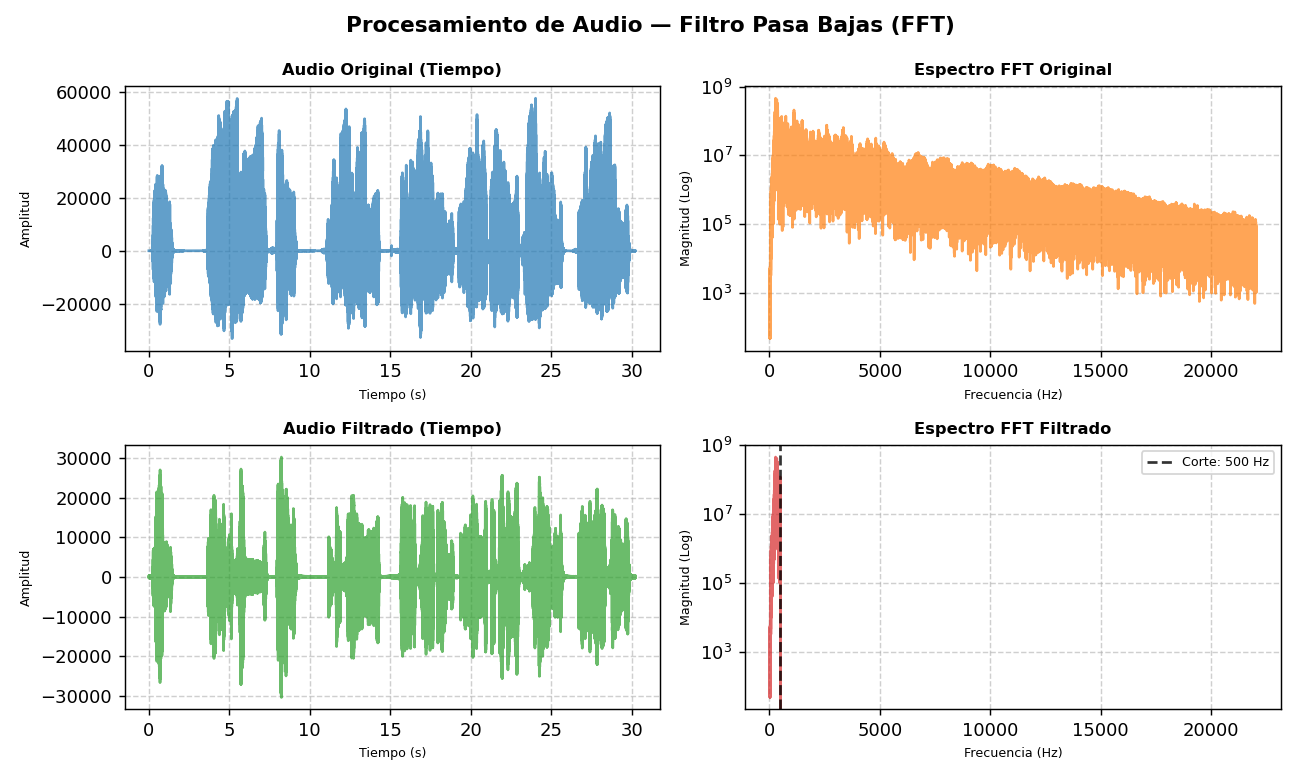

In [3]:
# --- Detectar automáticamente el archivo WAV más reciente en processed/ ---
import glob, os
_wav_files = sorted(
    glob.glob('processed/*.wav'),
    key=os.path.getmtime,
    reverse=True
)
if not _wav_files:
    raise FileNotFoundError("No se encontró ningún archivo .wav en la carpeta processed/")
input_path = _wav_files[0]

output_path = f'uploads/filtered_{Path(input_path).stem}.wav'

result = process_wav_file(input_path, output_path, 500) # --- Cambiar la frecuencia

from IPython.display import HTML, display as ipy_display, Audio
import io, base64, matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np

reduction = (1 - result['filtered_energy'] / result['original_energy']) * 100
reduction_color = '#e74c3c' if reduction > 0 else '#2ecc71'

# --- Leer template externo ---
with open('resultado_template.txt', 'r', encoding='utf-8') as _f:
    _tpl = _f.read()

html_metrics = _tpl.format(
    input=result['input'],
    output=result['output'],
    fs=result['fs'],
    duration_s=result['duration_s'],
    cutoff_freq=int(result['cutoff_freq']),
    original_energy=f"{result['original_energy']:.2f}",
    filtered_energy=f"{result['filtered_energy']:.2f}",
    reduction=f"{reduction:.1f}",
    reduction_color=reduction_color,
)

# --- Gráfica usando los datos exactos del filtro (no re-leer el WAV) ---
_data    = result['_data_plot']
_dfilt   = result['_data_filtered']
X        = result['_X']
Xf       = result['_X_filtered']
freqs    = result['_freqs']
fs_val   = result['fs']
cutoff   = result['cutoff_freq']

N      = len(_data)
half   = N // 2
t      = np.arange(N) / fs_val
pfreqs = freqs[:half]

fig, axs = plt.subplots(2, 2, figsize=(10, 6))
fig.suptitle('Procesamiento de Audio — Filtro Pasa Bajas (FFT)', fontsize=12, fontweight='bold')

axs[0,0].plot(t, _data, color='#1f77b4', alpha=0.7)
axs[0,0].set_title('Audio Original (Tiempo)', fontsize=9, fontweight='bold')
axs[0,0].set_xlabel('Tiempo (s)', fontsize=7); axs[0,0].set_ylabel('Amplitud', fontsize=7)
axs[0,0].grid(True, linestyle='--', alpha=0.6)

axs[0,1].plot(pfreqs, np.abs(X[:half]), color='#ff7f0e', alpha=0.7)
axs[0,1].set_title('Espectro FFT Original', fontsize=9, fontweight='bold')
axs[0,1].set_xlabel('Frecuencia (Hz)', fontsize=7); axs[0,1].set_ylabel('Magnitud (Log)', fontsize=7)
axs[0,1].set_yscale('log'); axs[0,1].grid(True, linestyle='--', alpha=0.6)

axs[1,0].plot(t, _dfilt, color='#2ca02c', alpha=0.7)
axs[1,0].set_title('Audio Filtrado (Tiempo)', fontsize=9, fontweight='bold')
axs[1,0].set_xlabel('Tiempo (s)', fontsize=7); axs[1,0].set_ylabel('Amplitud', fontsize=7)
axs[1,0].grid(True, linestyle='--', alpha=0.6)

axs[1,1].plot(pfreqs, np.abs(Xf[:half]), color='#d62728', alpha=0.7)
axs[1,1].set_title('Espectro FFT Filtrado', fontsize=9, fontweight='bold')
axs[1,1].set_xlabel('Frecuencia (Hz)', fontsize=7); axs[1,1].set_ylabel('Magnitud (Log)', fontsize=7)
axs[1,1].set_yscale('log')
axs[1,1].axvline(x=cutoff, color='black', linestyle='--', alpha=0.8, label=f'Corte: {int(cutoff)} Hz')
axs[1,1].legend(fontsize=7); axs[1,1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
buf = io.BytesIO()
plt.savefig(buf, format='png', dpi=130)
plt.close()
buf.seek(0)
img_b64 = base64.b64encode(buf.read()).decode()

# --- Layout lado a lado ---
combined = f"""
<div style="display:flex; gap:20px; align-items:flex-start; flex-wrap:wrap;">
  <div style="flex:0 0 auto;">
    <img src="data:image/png;base64,{img_b64}" style="max-width:755px; border-radius:10px; box-shadow:0 4px 16px rgba(0,0,0,0.15);">
  </div>
  <div style="flex:1 1 280px; min-width:260px;">
    {html_metrics}
  </div>
</div>
"""

ipy_display(HTML(combined))
ipy_display(Audio(result['output'], rate=result['fs']))


---

## 📝 Notas técnicas y recomendaciones

### Sobre el archivo de entrada
- Debe ser formato WAV (`.wav`) legible por `scipy.io.wavfile`.
- Si el audio es estéreo, el código toma solo el **canal izquierdo** para simplificar.
  Si necesitas procesar ambos canales, tendrías que llamar a `lowpass_filter` dos veces.
- El resultado filtrado se guarda en `uploads/filtered_<nombre>.wav` por defecto.

### Sobre la normalización
- La señal se normaliza a `[-1, 1]` antes de la FFT para trabajar con valores
  de punto flotante bien condicionados.
- Después de la IDFT, se renormaliza y convierte a `int16` antes de guardar,
  que es el formato estándar de los WAV de 16 bits.
- Sin esta renormalización el audio guardado podría salir silencioso o saturado.

### Sobre la frecuencia de muestreo
- La frecuencia de muestreo `fs` determina el rango de frecuencias que puede
  representar la señal. El **teorema de Nyquist** dice que la frecuencia máxima
  representable es `fs / 2`.
- Un WAV a 44 100 Hz puede representar frecuencias de hasta 22 050 Hz
  (rango completo de la audición humana).
- Si pones una `cutoff_freq` mayor que `fs / 2`, el filtro no tendrá efecto.

### Sobre el filtro rectangular
- El filtro aplicado aquí es ideal en el sentido matemático (corte perfecto),
  pero en la práctica puede producir un leve "tintinear" en el audio
  (fenómeno de Gibbs) cuando el corte es muy abrupto.
- Para audio de producción se recomiendan filtros con pendiente suave:
  Butterworth (`scipy.signal.butter`), FIR, etc.

### Experimentación sugerida
- Prueba distintos valores de `cutoff_freq` y escucha la diferencia.
- Agrega una celda extra que muestre el espectrograma con `plt.specgram(data, Fs=fs)`.
- Prueba con un filtro pasa altas invirtiendo la máscara: `np.abs(freqs) >= cutoff_freq`.
